# Introduction to Image Processing
## Assignment 2

**Deadline: 9th June EOD**

---

### Instructions
- Attempt all questions.
- Write clean and readable code.
- Explain theoretical answers in your own words in the text cell in notebook (.ipynb), not as comments in code cells.
- Use comments wherever necessary.
- You may use NumPy and Pillow library.


# Question 1: Understanding Digital Images (Easy)

A grayscale image is represented by:

|20|40|60|
|--|--|--|
|80|100|120|
|140|160|180|


## Part A (Theory)

1. What is a pixel?
2. What does the value 0 represent in a grayscale image?
3. What does the value 255 represent?
4. How many pixels are present in the image above?


### Theory Answer Space

Write your answer here.

1.An image consists of tiny picture elements called pixels.

Pixel = Picture Element

2.0 in a grayscale image represents Black.

3.255 in a grayscale image represents White.

4.There are 9 pixels in given image.

## Part B (Coding)

Write a Python program that:

1. Stores the matrix using NumPy.
2. Prints image dimensions.
3. Finds:
   - Minimum pixel value
   - Maximum pixel value
   - Average pixel value


In [2]:
# Write your solution here
#1.
import numpy as np
grayscale_image  = np.array([[20, 40, 60], [80, 100, 120],[140, 160, 180]])
#2.
print("Image dimension:",grayscale_image.shape)
#3.
print("Minimum pixel value:",np.min(grayscale_image))
print("Maximum pixel value:",np.max(grayscale_image))
print("Average pixel value:", np.average(grayscale_image))

Image dimension: (3, 3)
Minimum pixel value: 20
Maximum pixel value: 180
Average pixel value: 100.0


# Question 2: RGB Image Analysis (Medium)

Consider the RGB pixel values:

```text
(255,0,0)
(0,255,0)
(0,0,255)
(255,255,0)
(255,255,255)
```


## Part A (Theory)

1. What does RGB stand for?
2. Why are three channels used?
3. What color is produced by:
   - (255,255,0)
   - (255,0,255)
   - (0,255,255)
4. Explain why RGB is suitable for digital displays.


### Theory Answer Space

Write your answer here.

1. RGB stands for Red, Green and Blue color.

2. Human eyes contain receptors sensitive to red, green, and blue wavelengths.

Combining these colors creates almost every visible color. That's why three channels are used.

3. YELLOW

MAGENTA

CYAN

4. RGB (Red, Green, Blue) is suitable for digital displays because screens emit light directly. RGB uses the three primary colors of light: red, green, and blue. By combining these colors at different intensities, a display can produce millions of different colors.Each color can be represented numerically (usually from 0 to 255), which is convenient for computers and electronic devices.

## Part B (Coding)

Create a NumPy array containing at least 10 RGB pixels.

Write a program that:

1. Calculates average Red value.
2. Calculates average Green value.
3. Calculates average Blue value.
4. Finds the brightest pixel using:

`Brightness = (R + G + B) / 3`


In [3]:
# Write your solution here
import numpy as np
image = np.array([[255, 0, 0],
                  [0, 255, 0],
                  [0, 0, 255],
                  [255, 255, 255],
                  [0, 0, 0],
                  [255, 255, 0],
                  [255, 0, 255],
                  [0, 255, 255],
                  [0, 128, 255],
                  [160, 255, 0]])
#1.
print("Average Red value:",np.average(image[:,0]))
#2.
print("Average Green value:",np.average(image[:,1]))
#3.
print("Average Blue value:",np.average(image[:,2]))
#4.
brightness = np.array(np.mean(image, axis = 1))
position = np.unravel_index(np.argmax(brightness), brightness.shape)
print(position)

Average Red value: 118.0
Average Green value: 140.3
Average Blue value: 127.5
(np.int64(3),)


# Question 3: Image Cropping and Resizing (Medium)

Load any image using Pillow.

*[If you are reading this that means you are not using any LLM directly, so please add any funny **donald trump** image here :-)]*


## Part A (Theory)

1. What is cropping?
2. What is ROI (Region of Interest) and its use case?
3. What is aspect ratio, and why should it be preserved?


### Theory Answer Space

Write your answer here.

1. Cropping extracts a region from an image.

2. ROI(Region of Interest)-The selected crop area is called the Region of Interest.

Use Case:

Reduces computation.

Removes unwanted regions.

Focuses processing.

3. Aspect Ratio is the ratio of width and height.

Maintaining aspect ratio prevents distortion.

## Part B (Coding)

Write a program that:

1. Loads an image.
2. Displays original dimensions.
3. Crops the center region.
4. Resizes the cropped image to:
   - 300 × 300
   - 600 × 600
5. Save all generated images.


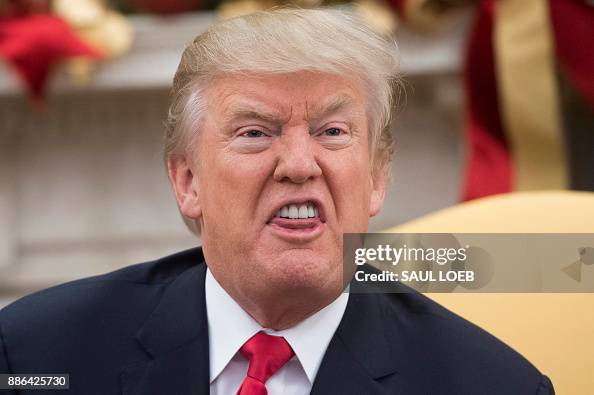

Original Dimensions: (395, 594, 3)


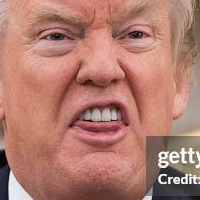

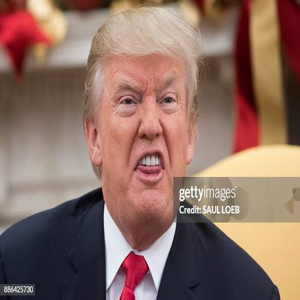

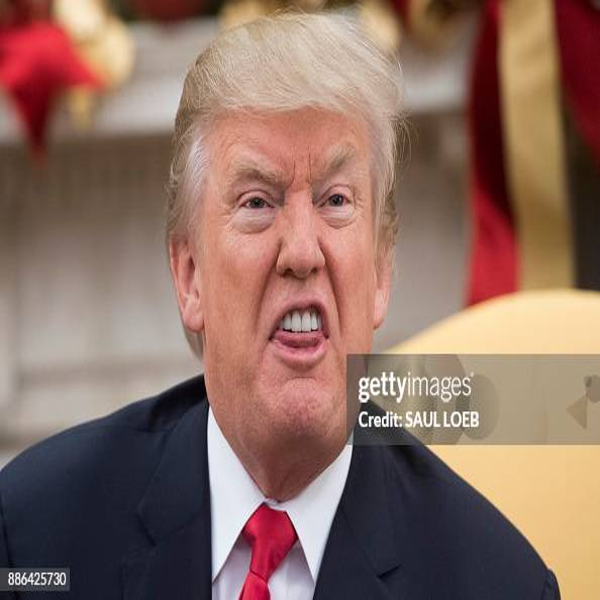

In [4]:
# Write your solution here
#1.
from PIL import Image
import numpy as np
img = Image.open("donalduck.jpg")
display(img)
#2.
image = np.array(img)
print("Original Dimensions:", image.shape)
#3.
width, height =  img.size
crop_width = 200
crop_height = 200

left = (width - crop_width) // 2
top = (height - crop_height) // 2
right = left + crop_width
bottom = top + crop_height

cropped = img.crop((left, top, right, bottom))
display(cropped)
#4.
resized1 = img.resize((300,300))
display(resized1)
resized2 = img.resize((600,600))
display(resized2)
#5.
img.save("img.jpg")
cropped.save("cropped.jpg")
resized1.save("resized1.jpg")
resized2.save("resized2.jpg")

## Part C (Analysis)

Compare the original image and resized images.

Discuss:
- Quality changes
- Distortion (if any)
- Aspect ratio effects


### Analysis Answer Space

Write your answer here.

####Quality Changes

1. The dimensions of the resized image is not changed much more in 600 x 600 in image so its quality doesn't changed that much. But in 300 x 300 the quality of the image looks a little bit blurry as some of its details is lost.

####Distortion

1. Both the resized image is distorted, both one is vertically stretched or horizontally compressed due to change in aspect ratio.

####Aspect Ratio Effects

1. The aspect ratio of the originl image is around 1.5 which is changed to 1 in both the resized image. this is the reason why both the resized images looks vertically stretched.



# Question 4: Interpolation Investigation (Hard)

Different interpolation techniques produce different results.


## Part A (Theory)

Research and explain:

1. Nearest Neighbor Interpolation
2. Bilinear Interpolation
3. Bicubic Interpolation
4. Lanczos Interpolation

For each method discuss:
- Working principle
- Advantages
- Disadvantages
- Suitable applications


### Theory Answer Space

Write your answer here.

1. Nearest Neighbour Interpolation

**Working Principle**-Nearest Neighbor Interpolation assigns the value of the closest pixel from the original image to each new pixel in the resized image.

**Advantages**-Very fast and simple to implement.
Requires low computational power.
Preserves sharp edges in pixel-art and low-resolution graphics.

**Disadvantages**-Produces blocky or pixelated images.
Creates jagged edges when enlarging images.
Poor visual quality for photographs.

**Suitable Applications**-Pixel art and retro-style graphics.Simple image processing tasks where quality is not critical.

2. Bilinear Interpolation

**Working Principle**-Bilinear Interpolation calculates the value of a new pixel by taking a weighted average of the four nearest neighboring pixels.

**Advantages**-Produces smoother images than Nearest Neighbor.
Reduces pixelation and jagged edges.
Computationally efficient.

**Disadvantages**-Can blur image details and edges.
Lower quality than Bicubic and Lanczos interpolation.

**Suitable Applications**-General image resizing.
Real-time graphics applications.
Situations requiring a balance between quality and speed.

3. Bicubic Interpolation

**Working Principle**-Bicubic Interpolation calculates new pixel values using the weighted average of the nearest 16 surrounding pixels. It uses cubic functions to estimate pixel intensities.

**Advantages**-Produces smoother and sharper images than Bilinear Interpolation.
Preserves image details better.

**Disadvantages**-More computationally expensive than Nearest Neighbor and Bilinear methods.

**Suitable Application**-Digital photography.
Image editing software.
High-quality image enlargement and scaling.

4. Lanczos Interpolation

**Working Principle**-Lanczos Interpolation uses a sinc-based mathematical function and considers a larger neighborhood of pixels to calculate new pixel values. This helps preserve fine image details during resizing.

**Advantages**-Produces very high-quality resized images.
Preserves edges and fine details effectively.
Generates sharp and natural-looking results.

**Disadvantages**-Computationally intensive and slower than other methods.
May produce slight ringing or halo artifacts around sharp edges.

**Suitable Application**-Professional image processing.
High-quality photo enlargement and reduction.
Printing, publishing, and scientific imaging applications.

## Part B (Coding)

Using the same image:

1. Resize the image to 100x100.
2. Resize it back to 800x800 using:
   - Nearest Neighbor
   - Bilinear
   - Bicubic
   - Lanczos
3. Save all outputs.


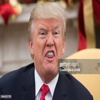

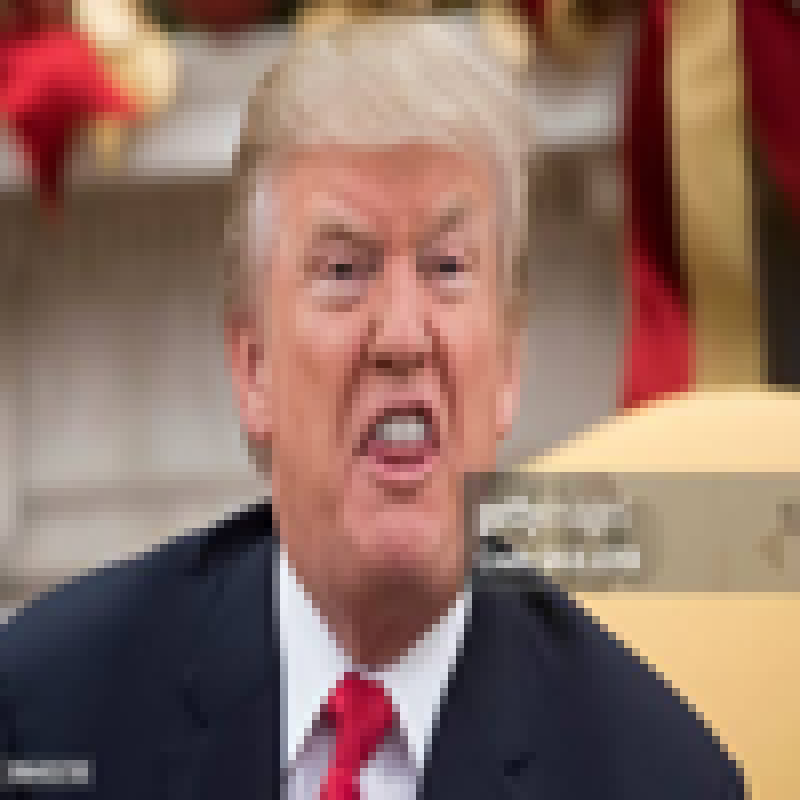

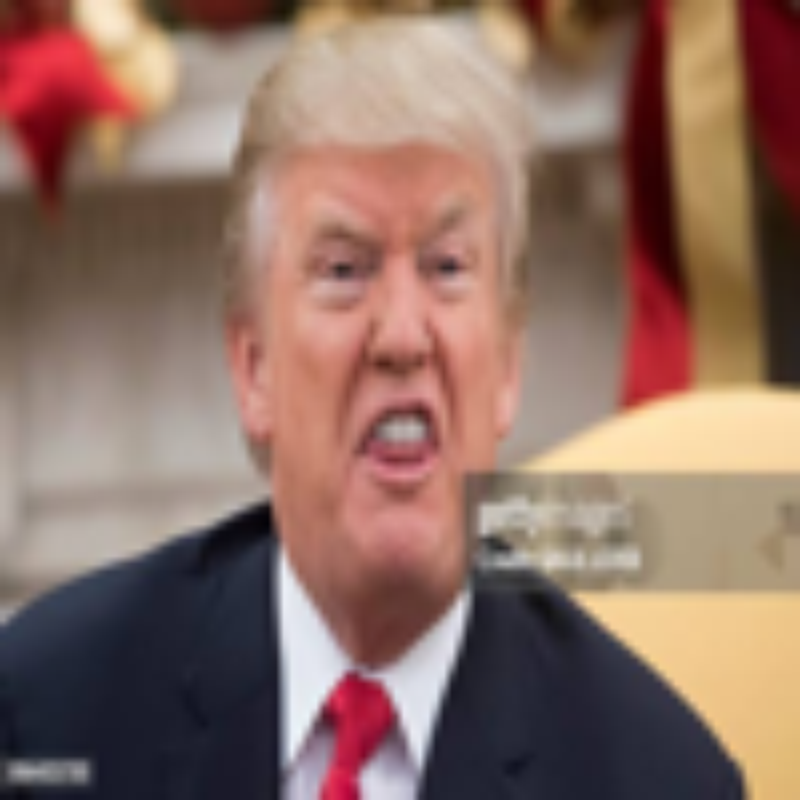

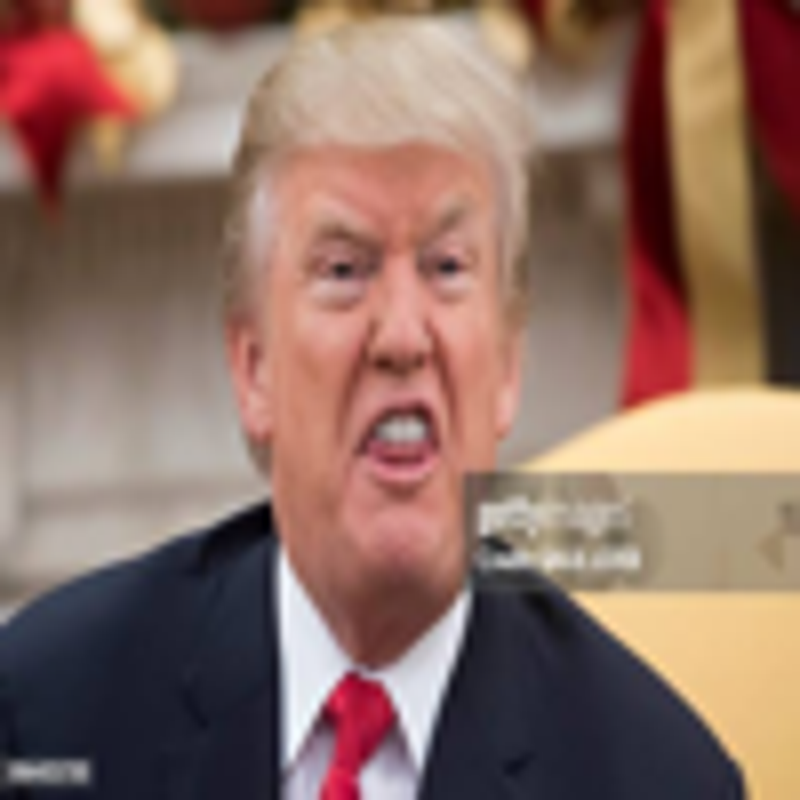

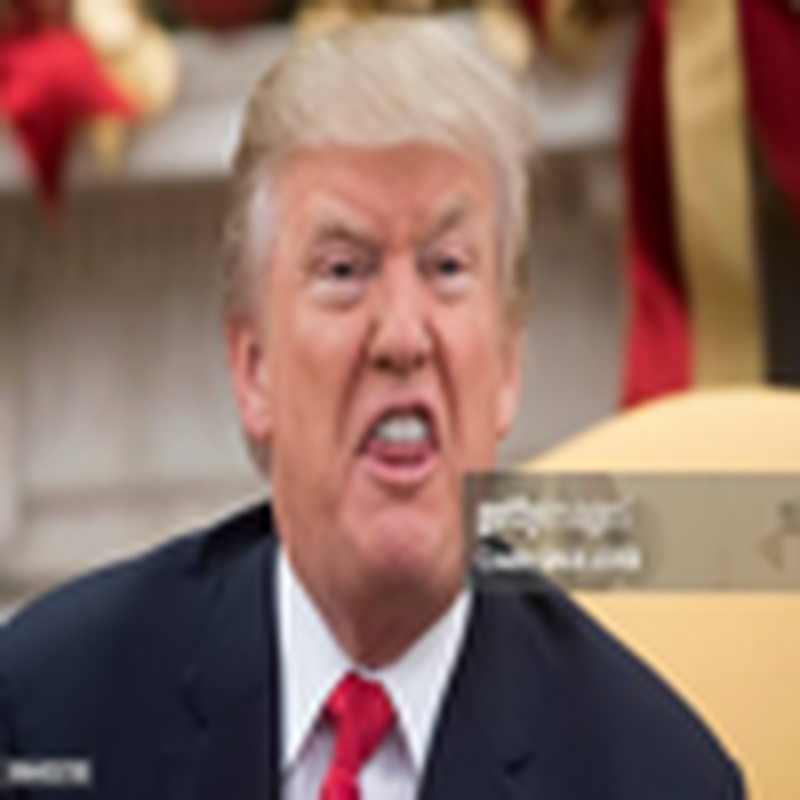

In [5]:
# Write your solution here
#1.
small = img.resize((100,100))
display(small)
#2.
nearest = small.resize((800, 800), Image.Resampling.NEAREST)
display(nearest)
bilinear = small.resize((800, 800), Image.Resampling.BILINEAR)
display(bilinear)
bicubic = small.resize((800, 800), Image.Resampling.BICUBIC)
display(bicubic)
lanczos = small.resize((800, 800), Image.Resampling.LANCZOS)
display(lanczos)
#3.
small.save("resized.jpg")
nearest.save("nearest.jpg")
bilinear.save("bilinear.jpg")
bicubic.save("bicubic.jpg")
lanczos.save("lanczos.jpg")


## Part C (Analysis)

Compare all outputs and answer:

1. Which method preserved the most detail?
2. Which method appeared blurriest?
3. Which method is best for pixel art?
4. Which method would you choose for CubeCanvas and why?


### Analysis Answer Space

Write your answer here.

1. Lanczos Interpolation preserved the most detail.

2. Nearest Neighbour Interpolation appeared blurriest.

3. Nearest Neighbour Interpolation is best for Pixel Art.

4. Lanczos Method should be used in CubeCanvas as it produces very high-quality resized images, preserves edges and fine details effectively, generates sharp and natural-looking results.

# Question 5 (Mini Project - 50 Marks)

# Image Processing Explorer

Create a Python application that demonstrates all major concepts learned in this module.

Your application should:

1. Load an image.

   *(Spongebob image pl ;-))*

2. Display image dimensions.
3. Display aspect ratio.
4. Resize the cropped image to user-specified dimensions.
5. Generate outputs using:
   - Nearest Neighbor
   - Bilinear
   - Bicubic
   - Lanczos
6. Display pixel values at user-selected coordinates.
7. Compute:
   - Average Red value
   - Average Green value
   - Average Blue value
8. Save all generated images automatically.

## Bonus Features (Optional)

Implement any two:

1. Brightness adjustment.
2. Contrast adjustment.
3. Grayscale conversion.
4. Image rotation.
5. Histogram visualization.


Image Dimension: (1536, 1382, 3)
Aspect ratio: 0.8997395833333334

Cropped image saved.

Enter new width: 382
Enter new height: 536


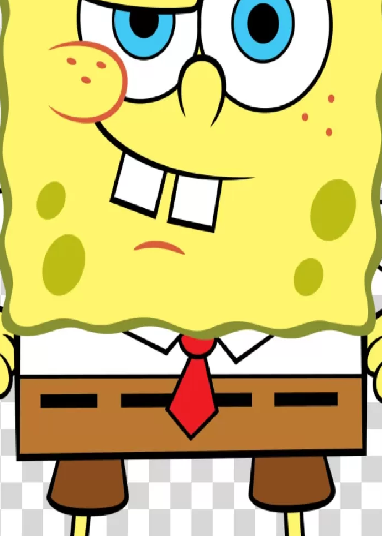

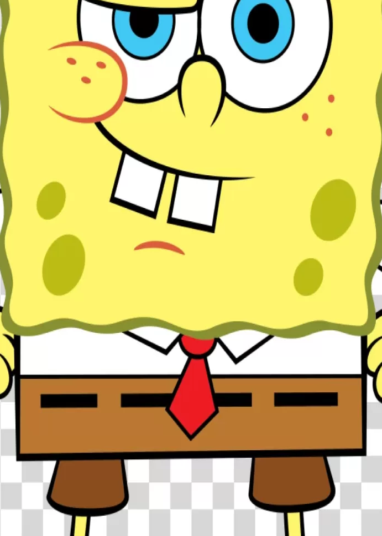

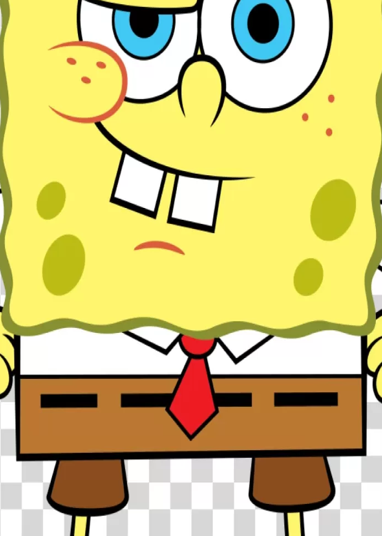

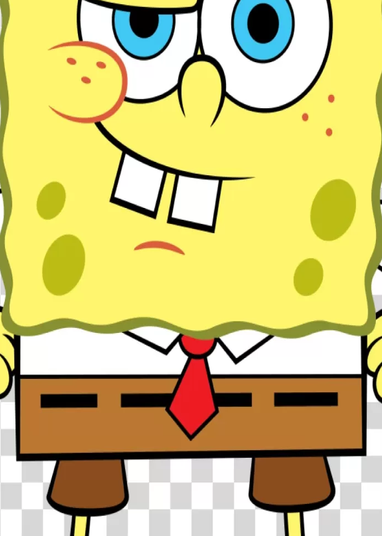


Enter X coordinate: 567
Enter Y coordinate: 876

Pixel at (567, 876) = [255 255 255]
Red  : 255
Green: 255
Blue : 255

Average Color Values
Average Red   : 223.1362175138688
Average Green : 219.33293714951157
Average Blue  : 191.9457242296792

All resized images saved successfully!


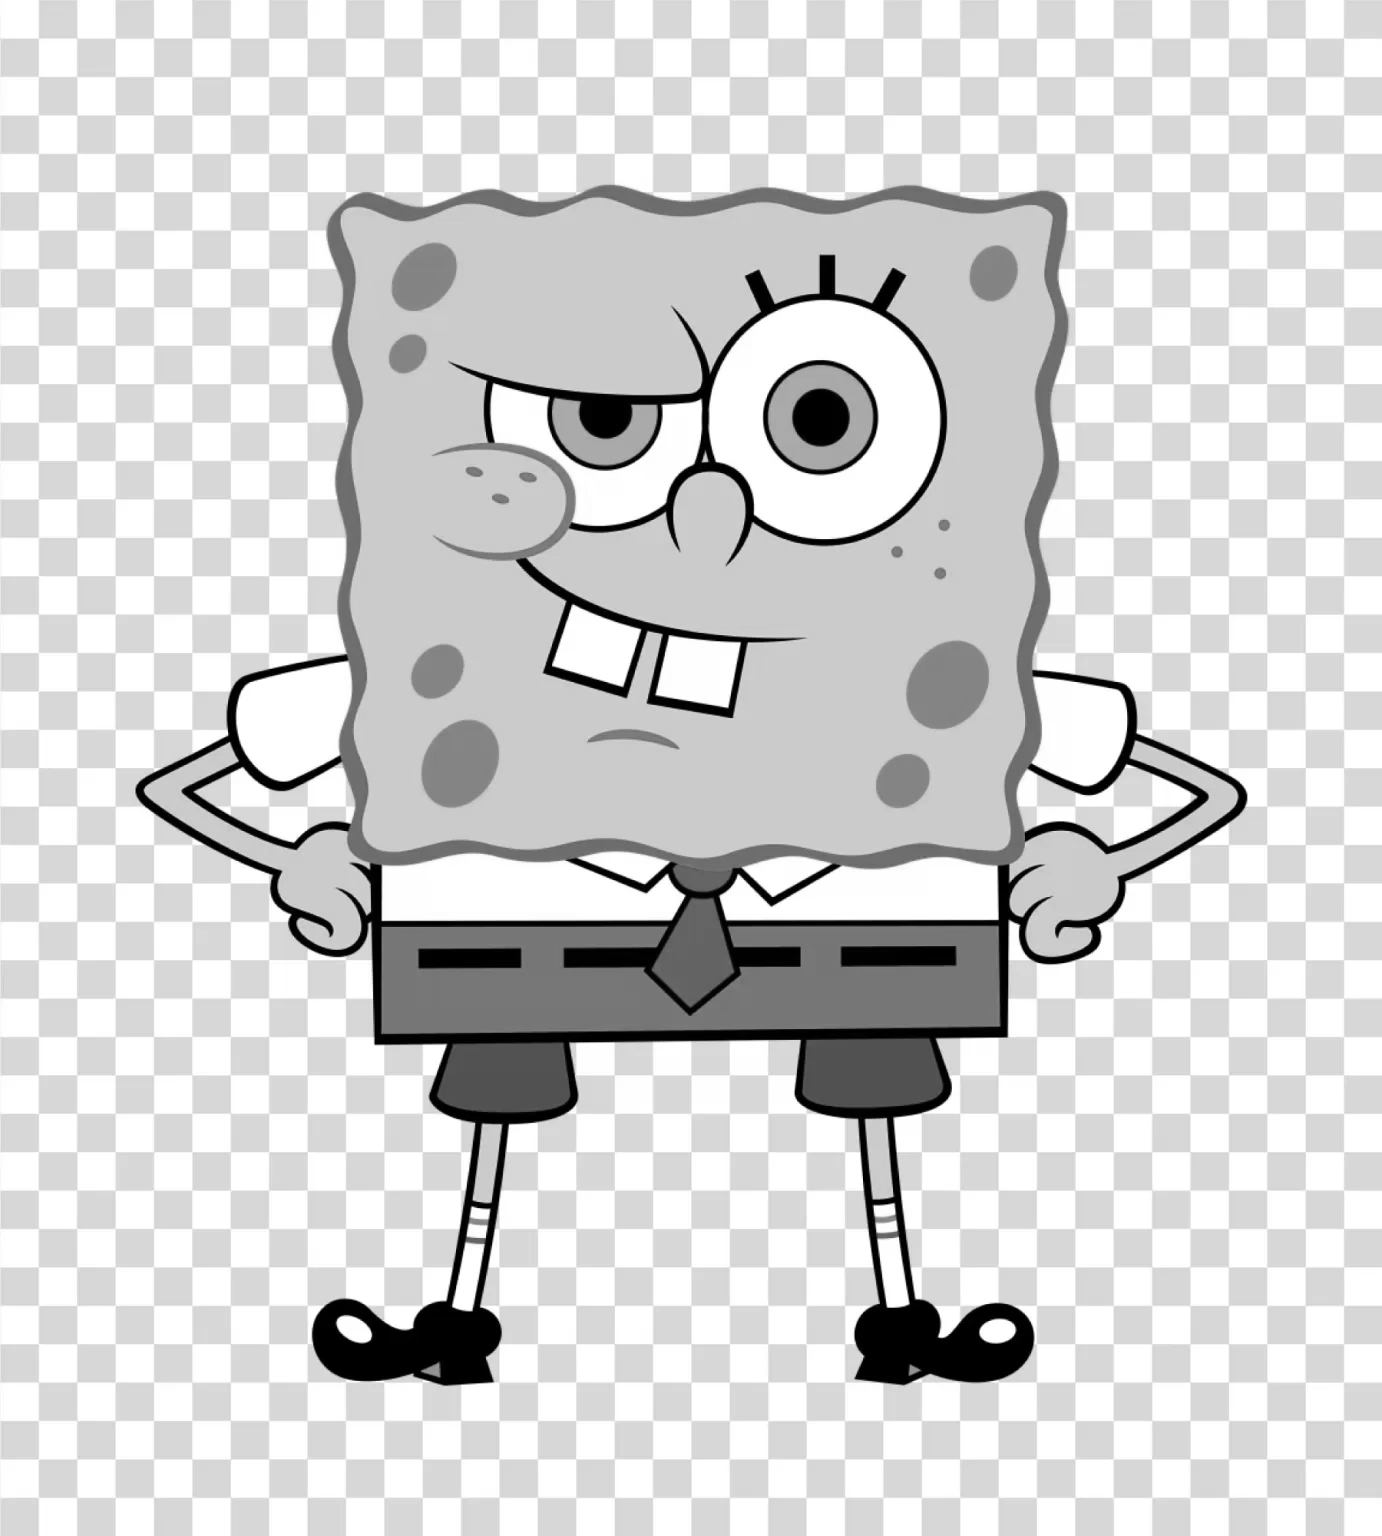

Grayscale image saved.


In [9]:
# Mini Project Solution
#1.
from PIL import Image
import numpy as np
img2 = Image.open("spongebob.jpg")
display(img2)
img_array = np.array(img2)
#2.
print("Image Dimension:",img_array.shape)
#3.
width, height = img2.size
print("Aspect ratio:",width/height)
#4.
crop_width = width // 2
crop_height = height // 2

left = (width - crop_width) // 2
top = (height - crop_height) // 2
right = left + crop_width
bottom = top + crop_height

cropped_img = img2.crop((left, top, right, bottom))
display(cropped_img)
cropped_img.save("cropped_image.jpg")

print("\nCropped image saved.")

new_width = int(input("\nEnter new width: "))
new_height = int(input("Enter new height: "))
#5.
nearest = cropped_img.resize(
    (new_width, new_height),
    Image.Resampling.NEAREST
)
display(nearest)

bilinear = cropped_img.resize(
    (new_width, new_height),
    Image.Resampling.BILINEAR
)
display(bilinear)

bicubic = cropped_img.resize(
    (new_width, new_height),
    Image.Resampling.BICUBIC
)
display(bicubic)

lanczos = cropped_img.resize(
    (new_width, new_height),
    Image.Resampling.LANCZOS
)
display(lanczos)

#6.
x = int(input("\nEnter X coordinate: "))
y = int(input("Enter Y coordinate: "))

if 0 <= x < width and 0 <= y < height:
    pixel = img_array[y, x]
    print(f"\nPixel at ({x}, {y}) = {pixel}")
    print("Red  :", pixel[0])
    print("Green:", pixel[1])
    print("Blue :", pixel[2])
else:
    print("Invalid coordinates!")

#7.
avg_red = np.mean(img_array[:, :, 0])
avg_green = np.mean(img_array[:, :, 1])
avg_blue = np.mean(img_array[:, :, 2])

print("\nAverage Color Values")
print("Average Red   :", avg_red)
print("Average Green :", avg_green)
print("Average Blue  :", avg_blue)

#8.
nearest.save("nearest_neighbor.jpg")
bilinear.save("bilinear.jpg")
bicubic.save("bicubic.jpg")
lanczos.save("lanczos.jpg")

print("\nAll resized images saved successfully!")

gray_array = np.mean(
    img_array,
    axis=2
).astype(np.uint8)

gray_img = Image.fromarray(gray_array)
display(gray_img)
gray_img.save("grayscale.jpg")

print("Grayscale image saved.")

## Project Notes / Explanation (if any)

Write your explanation here.